In [ ]:
%pip install transformers
%pip install datasets

%pip install torch torchvision torchaudio
%pip install transformers datasets
%pip install numpy pandas scikit-learn
%pip install "accelerate>=1.1.0"
%pip install scikit-learn

In [1]:
from datasets import load_dataset

# Load goEmotions Dataset and get Sentiment Labels
goEmotionsDataset = load_dataset('go_emotions')
sentimentLabels = goEmotionsDataset['train'].features['labels'].feature.names

/Users/donovanchen/UCI/CS175/RedditSentimentAnalysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from transformers import RobertaForSequenceClassification

model_name = 'cardiffnlp/twitter-roberta-base-sentiment'

# Download basic roBERTa model
model = RobertaForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(sentimentLabels),
    problem_type='multi_label_classification',
    ignore_mismatched_sizes=True
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2900.44it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |                                                                                        
--------------------------------+------------+----------------------------------------------------------------------------------------
roberta.embeddings.position_ids | UNEXPECTED |                                                                                        
classifier.out_proj.weight      | MISMATCH   | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([28, 768])
classifier.out_proj.bias        | MISMATCH   | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([28])          

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture;

In [3]:
import numpy as np

# Convert dataset sentiment keys into one hot encoding
def one_hot_encode(example):
    vector = np.zeros(28, dtype=np.float32)

    for label_index in example['labels']:
        vector[label_index] = 1.0

    return {'labels': vector}

dataset = goEmotionsDataset.map(one_hot_encode)

print("Original ID:", goEmotionsDataset['train'][0]['labels'])
print("New Vector:", dataset['train'][0]['labels'])

Original ID: [27]
New Vector: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]


In [4]:
from transformers import RobertaTokenizer
from datasets import Sequence, Value

# Tokenize and format for PyTorch
def tokenize_text(rows):
    return tokenizer(rows['text'], padding='max_length', truncation=True, max_length=128)

tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
tokenized_dataset = dataset.map(tokenize_text, batched=True)
tokenized_dataset = tokenized_dataset.cast_column("labels", Sequence(Value("float32")))
tokenized_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])


In [5]:
from sklearn.metrics import f1_score
import numpy as np

# Set up F1 Score
def compute_metrics(eval_pred):
    threshold = 0.3

    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    predictions = (probs > threshold).astype(int)
    return {'f1': f1_score(labels, predictions, average='weighted')}


In [6]:
import torch
import numpy as np

# 1. Extract labels from the tokenized training dataset
train_labels = np.array(tokenized_dataset['train']['labels'])

# 2. Calculate count of positives (1s) and negatives (0s) per class
pos_counts = np.sum(train_labels, axis=0)
neg_counts = len(train_labels) - pos_counts

# 3. Calculate pos_weight: (Number of Negatives) / (Number of Positives)
pos_weight_calc = neg_counts / (pos_counts + 1e-6)

# 4. Convert to Tensor for PyTorch
pos_weight_tensor = torch.tensor(pos_weight_calc, dtype=torch.float)

print("Calculated Class Weights (First 5):", pos_weight_tensor[:5])
print("Weight for rare classes (e.g., index 13):", pos_weight_tensor[13])

Calculated Class Weights (First 5): tensor([ 9.5109, 17.6469, 26.7026, 16.5749, 13.7703])
Weight for rare classes (e.g., index 13): tensor(49.8910)


In [ ]:
from transformers import TrainingArguments, Trainer
# from google.colab import drive
import os
from torch import nn
from transformers import Trainer

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        # 1. Pop labels from inputs (Trainer passes them in inputs dict)
        labels = inputs.get("labels")
        
        # 2. Forward pass
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        # 3. Define Weighted Loss
        loss_fct = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor.to(logits.device))
        
        # 4. Compute Loss
        loss = loss_fct(logits, labels.float())
        
        return (loss, outputs) if return_outputs else loss

# Re-define Training Arguments (Same as before, just ensuring context)
training_args = TrainingArguments(
    output_dir="./roberta-sentiment-model-weighted",
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1" # Ensure we optimize for F1, not loss
)

# Initialize the CUSTOM Trainer
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['validation'],
    compute_metrics=compute_metrics,
)

# Train
trainer.train()

# drive.mount('/content/drive', force_remount=True)
# model_path = "/content/drive/My Drive/RedditSentimentAnalysis/my_emotion_model"
model_path = "./saved_models/my_emotion_model"
trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)
print(f"Model successfully saved to: {model_path}")

In [14]:
from torch import topk
from transformers import pipeline

#Pipeline
model_path = "../.saved_models/UpdatedTwitterRoBERTa"

emotion_classifier = pipeline(
    "text-classification",
    model=model_path,
    tokenizer=model_path,
    truncation=True,
    max_length=512,
    topk=None
)

# Test
result = emotion_classifier("I am sorry for your loss", top_k=10)
for prediction in result:
    sentiment_id = int(prediction['label'].replace("LABEL_", ""))
    sentiment_name = goEmotionsDataset['train'].features['labels'].feature.names[sentiment_id]

    print(f"{sentiment_name}, Score: {prediction['score']}")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2272.29it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              


sadness, Score: 0.9865944385528564
remorse, Score: 0.9024558663368225
grief, Score: 0.873687744140625
caring, Score: 0.37334808707237244
disappointment, Score: 0.2578141987323761
gratitude, Score: 0.1582479327917099
surprise, Score: 0.047139573842287064
admiration, Score: 0.044274818152189255
anger, Score: 0.041798509657382965
curiosity, Score: 0.041591718792915344


In [15]:
from sklearn.metrics import f1_score
from transformers import RobertaForSequenceClassification, Trainer


model = RobertaForSequenceClassification.from_pretrained(model_path)
trainer = Trainer(model=model)

def optimize_thresholds(trainer, dataset):
    # 1. Get raw logits from the model
    predictions = trainer.predict(dataset)
    logits = predictions.predictions
    true_labels = predictions.label_ids
    
    # 2. Convert to probabilities
    probs = 1 / (1 + np.exp(-logits))
    
    best_thresholds = []
    best_f1s = []
    
    # 3. Iterate over all 28 labels
    for i in range(28):
        best_t = 0.5
        best_f1 = 0.0
        
        # Check thresholds from 0.1 to 0.9
        for t in np.arange(0.1, 0.95, 0.05):
            preds = (probs[:, i] >= t).astype(int)
            # Calculate F1 for this specific class
            score = f1_score(true_labels[:, i], preds, zero_division=0)
            
            if score > best_f1:
                best_f1 = score
                best_t = t
                
        best_thresholds.append(best_t)
        best_f1s.append(best_f1)
        
    return np.array(best_thresholds)

# Run optimization
optimal_thresholds = optimize_thresholds(trainer, tokenized_dataset['validation'])

print("Optimal Thresholds per class:")
for name, thresh in zip(sentimentLabels, optimal_thresholds):
    print(f"{name}: {thresh:.3f}")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1907.11it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
/Users/donovanchen/UCI/CS175/RedditSentimentAnalysis/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Optimal Thresholds per class:
admiration: 0.750
amusement: 0.650
anger: 0.900
annoyance: 0.500
approval: 0.650
caring: 0.700
confusion: 0.550
curiosity: 0.350
desire: 0.500
disappointment: 0.550
disapproval: 0.450
disgust: 0.750
embarrassment: 0.850
excitement: 0.350
fear: 0.400
gratitude: 0.650
grief: 0.300
joy: 0.750
love: 0.650
nervousness: 0.800
optimism: 0.850
pride: 0.850
realization: 0.900
relief: 0.650
remorse: 0.650
sadness: 0.800
surprise: 0.800
neutral: 0.200


In [16]:
from sklearn.metrics import classification_report
import numpy as np

# Test
predictions = trainer.predict(tokenized_dataset['test'])
logits = predictions.predictions
true_labels = predictions.label_ids

# Convert probabilities to class labels (0 or 1) using the 0.3 threshold we discussed for better recall
sigmoid_outputs = 1 / (1 + np.exp(-logits))
predicted_labels = (sigmoid_outputs > optimal_thresholds).astype(int)

# Print the detailed report
print(classification_report(
    true_labels,
    predicted_labels,
    target_names=sentimentLabels,
    zero_division=0
))

/Users/donovanchen/UCI/CS175/RedditSentimentAnalysis/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


                precision    recall  f1-score   support

    admiration       0.70      0.73      0.71       504
     amusement       0.74      0.91      0.82       264
         anger       0.57      0.37      0.45       198
     annoyance       0.33      0.53      0.41       320
      approval       0.39      0.43      0.41       351
        caring       0.40      0.41      0.40       135
     confusion       0.31      0.61      0.41       153
     curiosity       0.43      0.81      0.56       284
        desire       0.47      0.52      0.49        83
disappointment       0.24      0.38      0.30       151
   disapproval       0.34      0.53      0.41       267
       disgust       0.46      0.48      0.47       123
 embarrassment       0.52      0.35      0.42        37
    excitement       0.28      0.54      0.37       103
          fear       0.53      0.79      0.63        78
     gratitude       0.92      0.90      0.91       352
         grief       0.31      0.83      0.45  

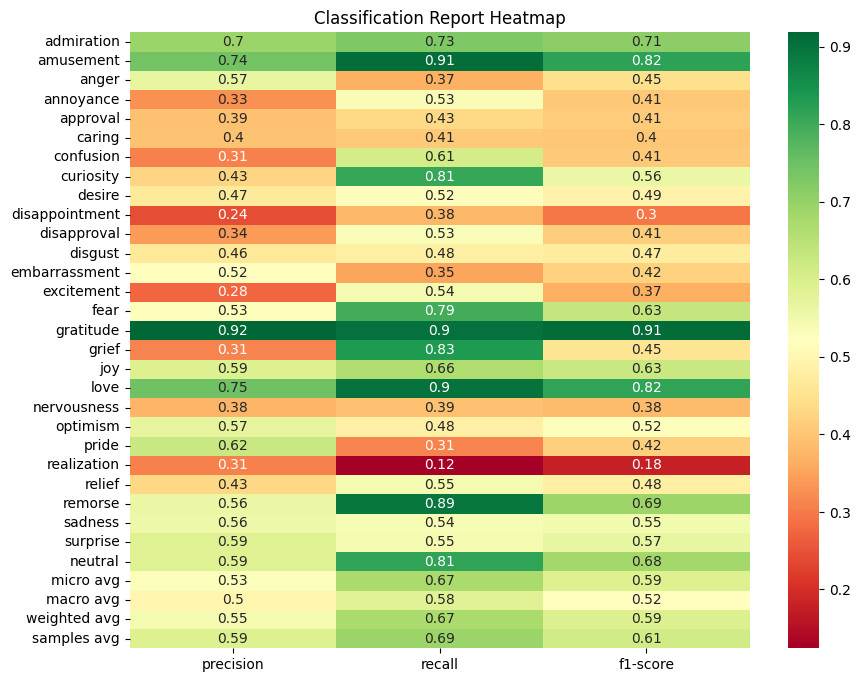

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

report_dict = classification_report(true_labels, predicted_labels, 
                                   target_names=sentimentLabels, 
                                   output_dict=True, zero_division=0)

# Convert to DataFrame and plot
report_df = pd.DataFrame(report_dict).iloc[:-1, :].T
plt.figure(figsize=(10, 8))
sns.heatmap(report_df, annot=True, cmap='RdYlGn')
plt.title("Classification Report Heatmap")
plt.show()

In [18]:
import numpy as np
from sklearn.metrics import classification_report

# 1. Define your Map
sentimentMap = {
  "positive": ["admiration", "amusement", "approval", "caring", "desire", "excitement", "gratitude", "joy", "love", "optimism", "pride", "relief"],
  "negative": ["anger", "annoyance", "disappointment", "disapproval", "disgust", "embarrassment", "fear", "grief", "nervousness", "remorse", "sadness"],
  "neutral": ["neutral", "realization", "surprise", "curiosity", "confusion"]
}

# 2. Pre-calculate indices to speed up processing
pos_indices = [sentimentLabels.index(e) for e in sentimentMap['positive'] if e in sentimentLabels]
neg_indices = [sentimentLabels.index(e) for e in sentimentMap['negative'] if e in sentimentLabels]
neu_indices = [sentimentLabels.index(e) for e in sentimentMap['neutral'] if e in sentimentLabels]

def get_bucket_preds(matrix):
    """
    Collapses 28-emotion vectors into 3-bucket vectors (Pos, Neg, Neu).
    Returns a list of single labels (0, 1, or 2).
    """
    bucket_preds = []
    for row in matrix:
        # We sum the scores/probabilities for each bucket
        pos_score = np.sum(row[pos_indices])
        neg_score = np.sum(row[neg_indices])
        neu_score = np.sum(row[neu_indices])

        # 0=Positive, 1=Negative, 2=Neutral (matches target_names order below)
        bucket_preds.append(np.argmax([pos_score, neg_score, neu_score]))
    return bucket_preds

probs = 1 / (1 + np.exp(-logits))

# 4. Generate Bucket Predictions
y_true_buckets = get_bucket_preds(true_labels)
y_pred_buckets = get_bucket_preds(probs)

# 5. Print Report
print("RoBERTa Baseline (Mapped to 3 Buckets):")
print(classification_report(
    y_true_buckets,
    y_pred_buckets,
    target_names=['Positive', 'Negative', 'Neutral']
))

RoBERTa Baseline (Mapped to 3 Buckets):
              precision    recall  f1-score   support

    Positive       0.80      0.82      0.81      2098
    Negative       0.66      0.74      0.70      1182
     Neutral       0.76      0.68      0.72      2147

    accuracy                           0.75      5427
   macro avg       0.74      0.75      0.74      5427
weighted avg       0.75      0.75      0.75      5427



In [19]:
import time

print("Starting latency test...")
start_time = time.time()

predictions = trainer.predict(tokenized_dataset['test'])

end_time = time.time()
total_time = end_time - start_time
num_samples = len(goEmotionsDataset['test'])

print(f"Processed {num_samples} samples in {total_time:.2f} seconds.")
print(f"Average Latency: {(total_time / num_samples) * 1000:.2f} milliseconds per post.")

Starting latency test...


/Users/donovanchen/UCI/CS175/RedditSentimentAnalysis/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Processed 5427 samples in 31.76 seconds.
Average Latency: 5.85 milliseconds per post.


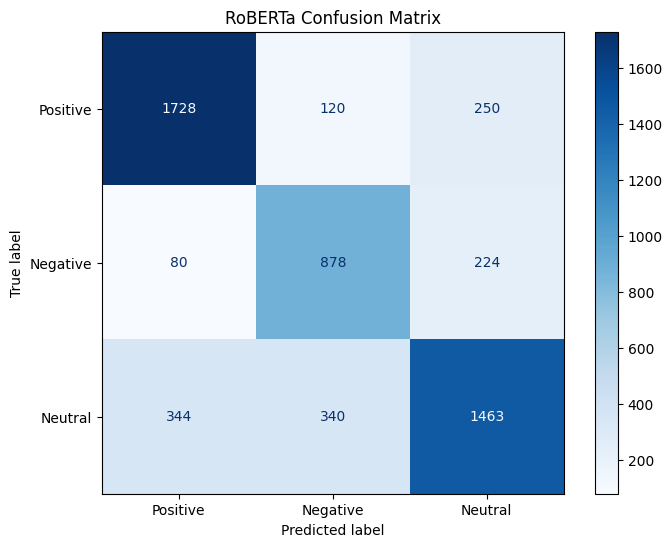

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_buckets, y_pred_buckets)
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Positive', 'Negative', 'Neutral'])

fig, ax = plt.subplots(figsize=(8, 6))
cmd.plot(cmap='Blues', ax=ax)
plt.title("RoBERTa Confusion Matrix")
plt.show()

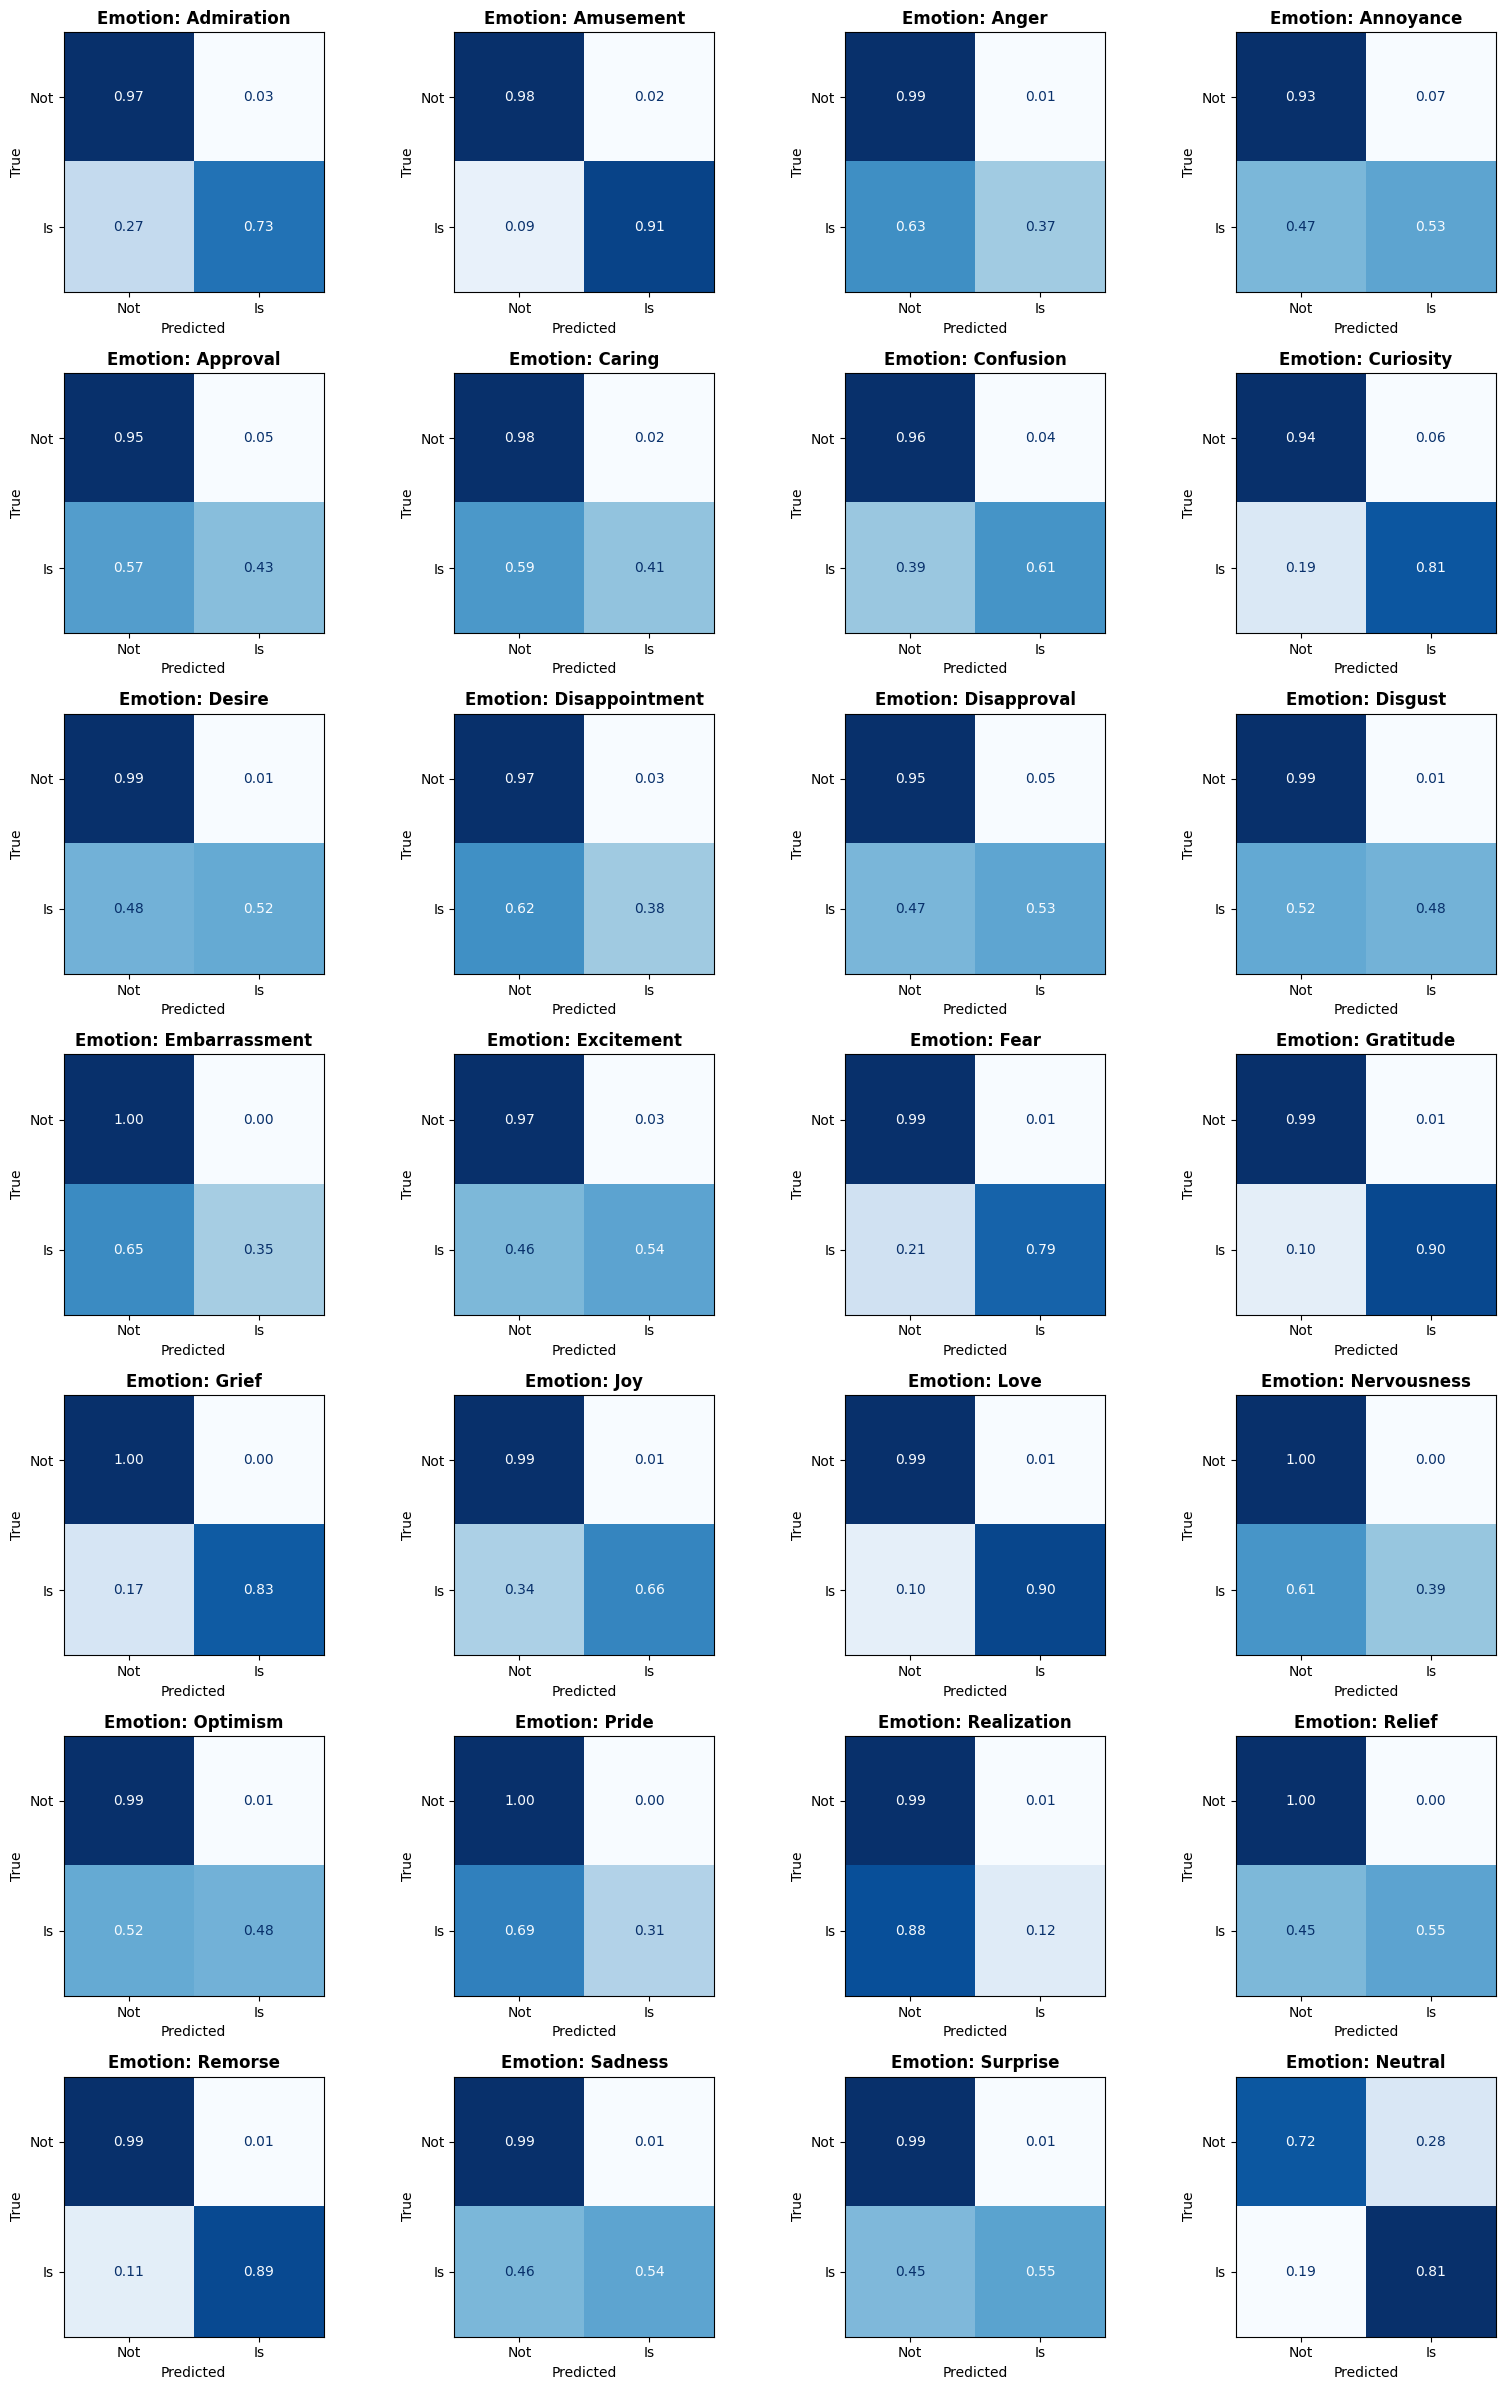

In [21]:
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 1. Generate the raw multi-label confusion matrices
mcm = multilabel_confusion_matrix(true_labels, predicted_labels)

# 2. Set up the grid
fig, axes = plt.subplots(7, 4, figsize=(16, 24))
axes = axes.ravel() 

# 3. Loop through and plot each emotion's normalized matrix
for i, (emotion_name, matrix) in enumerate(zip(sentimentLabels, mcm)):
    row_sums = matrix.sum(axis=1)
    matrix_normalized = np.divide(
        matrix.astype('float'), 
        row_sums[:, np.newaxis], 
        out=np.zeros_like(matrix, dtype=float), 
        where=row_sums[:, np.newaxis]!=0
    )
    
    # Create the display object
    disp = ConfusionMatrixDisplay(confusion_matrix=matrix_normalized, display_labels=['Not', 'Is'])
    
    # Plot it (switched values_format to '.2f' for decimals)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='.2f')
    
    axes[i].set_title(f"Emotion: {emotion_name.capitalize()}", fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')

# 4. Adjust spacing and show
plt.tight_layout()
plt.show()